# Star Multi-Class Classification Neural Network With Pytorch

## Introduction:

Whenever I hear any stories about stars far far away from earth, Im talking millions of light years away not possibly seen visually through any telescope, I always wonder: <center> *"How on earth (pun intended) do they find out what typa star it is from this far away?!"* </center>  
And to satisfy this curiousity, I did a little google search and found out that every star has its own life cycle, ranging from a few million to trillions of years, and its properties change as it ages. And by measuring these properties, we can deduce the type of star.

But I'm not satisfied until I do it myself. So in this notebook I'll be writing a model that classifies a star's type based on it's features. (And also serve as a good practice for Pytorch)

## Dataset

The dataset consists of 6 collumns.
- The Temperature of the star
- The Luminosity of the star
- It's Radius
- It's Absolute Magnitude
- It's General Color of Spectrum
- The Spectral Class

Everything should be obvious, however the Spectral Class might be news.  
An asteroid spectral type is assigned to asteroids based on their reflectance spectrum (its effectiveness in reflecting radiant energy)

In [17]:
import os
from pathlib import Path

iskaggle = os.environ.get("KAGGLE_KERNEL_RUN_TYPE", '')
if iskaggle: path = Path('../input/star-type-classification')
else:
    path = Path('data')

#### Here's a quick look at the data:

In [18]:
import pandas as pd

data = pd.read_csv(path/'Stars.csv')
data

,temperature,luminosity,radius,magnitude,color,class,label
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Blue,O,5
236,30839,834042.000000,1194.0000,-10.63,Blue,O,5
237,8829,537493.000000,1423.0000,-10.73,White,A,5
238,9235,404940.000000,1112.0000,-11.23,White,A,5


#### Sampling the dataset is cool and all, but we wanna see some more important information

In [19]:
data.describe()

,temperature,luminosity,radius,magnitude,label
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


#### Quick Overview
Some values differ alot, and this outliers are not very good for writing a model that can generalize to new data.  
The smallest value for luminosity is as low as 0.00008 (That's 4 zeros!!) whereas the largest gets up to ~850,000  
Now come's a dillemma: <center>*"Should I normalize the data, or preserve their differences?"*</center>  
Best way to know, is to check if these overly small/huge values are truly outliers and must be normalized.

<Axes: >

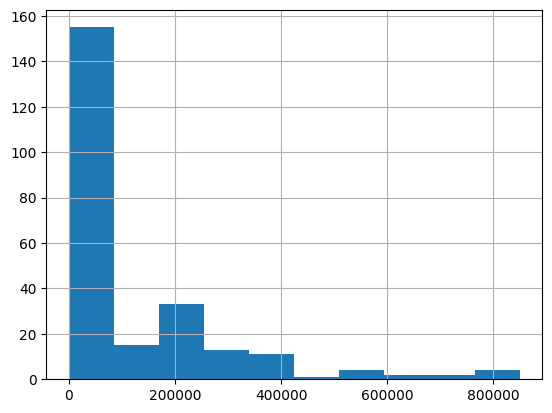

In [20]:
data['luminosity'].hist()

Almost half of the dataset has it's luminosity in the decimals!! With the rest being in the hundreds of thousands.  
Alright, we'll have to normalize this. I'll use Z-Score which will transform the dataset into having a mean of 0 and a standard deviation of 1.
$$
z = \frac{x - \mu}{\sigma}
$$
It's very simple, you subtract the original value by the mean of the column, and divide that by the standard deviation.

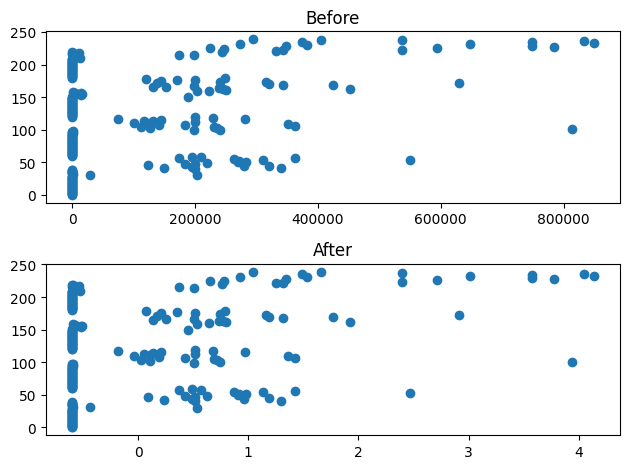

In [21]:
import torch
import matplotlib.pyplot as plt

def z_score(x): return (x - torch.mean(x)) / torch.std(x)

normalized_luminosity = z_score(torch.tensor(data.luminosity))



plt.subplot(2, 1, 1)
plt.scatter(data['luminosity'].to_numpy(), range(240))
plt.title('Before')
plt.subplot(2, 1, 2)
plt.scatter(normalized_luminosity.numpy(), range(240))
plt.title('After')
plt.tight_layout()
plt.show()

#### From hundreds of thousand's to single digits, while still preserving the data's structure! Perfect!

---

#### Preparation

Now ill convert the dataframe into a tensor and prepare it to be chucked into a neural network.  
This dataset already is very well-put together. There are no nil values, however there is a need for dummy columns.

So let's make this quick, and get it over with!

First up is defining the dependant and independant variables as tensors

In [22]:
import numpy as np

t_dep = torch.tensor(data['label'])
t_indep = torch.tensor(data.drop(columns=['label']).astype(np.float32).values, dtype=torch.float)

ValueError: could not convert string to float: 'Red'

Oh golly jargon!! Damn, what went wrong?!
Let's see here..

```
ValueError: could not convert string to float: 'Red'
```

We tried to convert a word into a number!  
Ah.. almost forgot math needs numbers..

### Dummy Columns

In [23]:
data['color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'yellowish',
       'Yellowish', 'Orange-Red', 'Blue-White'], dtype=object)

As we can see, the color column has 17 possible colors a star can be.  
However, since we can only accept numbers, an easy fix is using **Dummy Columns**  

Ill give you an example, say we had data for a group of people. One of the columns is "Gender" where each person could have the value "Female" or "Male". To turn these into numbers, we'll create 2 new columns:
- "Female?"
- "Male?"

Say you have bob, a professional male specializing in being a man. His female column would be "0" for false, and his male column would be "1" for true.  
Boom!! Problem solved.

So to apply this here, we'll just make 17 columns for every color of star.

In [24]:
data = pd.get_dummies(data, columns=['color', 'class'])
data[["color_Red", "color_Blue White", "color_White", "color_Yellowish White", "color_Blue white", "color_Pale yellow orange", "color_Blue", "color_Blue-white", "color_Whitish", "color_yellow-white", "color_Orange", "color_White-Yellow", "color_white", "color_yellowish", "color_Yellowish", "color_Orange-Red", "color_Blue-White"]].sample(5)

,color_Red,color_Blue White,color_White,color_Yellowish White,color_Blue white,color_Pale yellow orange,color_Blue,color_Blue-white,color_Whitish,color_yellow-white,color_Orange,color_White-Yellow,color_white,color_yellowish,color_Yellowish,color_Orange-Red,color_Blue-White
202,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
56,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
103,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
176,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
8,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Phew, let's try this again now.

In [25]:
import numpy as np
t_dep = torch.tensor(data['label'])
t_indep = torch.tensor(data.drop(columns=['label']).astype(np.float32).values, dtype=torch.float)
t_indep = (t_indep - t_indep.mean()) / t_indep.std()

No errors! Eureka!

## Defining the Neural Network

For the math-focused nerds, you can imagine a neural network simply as one big ol' composite function. Multiple layers, with each layer containing multiple units, and each unit taking in a matrix as input, multipliying it with a matrix of coefficients.

The main import thing to remember for the coefficients, is their matrix dimensions. Let's say we have the shape of a matrix of coefficients as [x, y]:
- x: Number of units of previous layer
- y: Number of units of next layer

First function we must define is one to [initialize the coeffs](#initalizing-the-coeffs)  
We'll create the number of hiddens layers, and units in each layer. Then, we'll loop over each hidden layer to create randomized matricies of parameters and constants in correct shape.  

<image src='image1.png'></image>

Quick note:
> The values in the matricies of parameters MUST be randomized. Since during backpropagation, initializing all parameters to 0 will result in identical gradients that would effectivally cancel the training out.

# initializing the coeffs

In [26]:
n_coeffs = t_indep.shape[1]

def init_coeffs():
    hiddens = [10, 10] # Update for each hidden layer
    sizes = [n_coeffs] + hiddens + [6]
    n = len(sizes)
    layers = [(torch.randn(sizes[i], sizes[i+1])) * 0.1 for i in range(n-1)]
    consts = [torch.randn(1, sizes[i+1]) for i in range(n-1)]
    for layer in layers + consts: layer.requires_grad_()
    return layers, consts

If this was NumPy, I would be forced to calculate the derivatives for all parameters in the neural network. Yes, id automate it in a loop. But since I really only have an intuative understanding of derivatives, i never fully understand whats going on.

Luckily for us, in PyTorch, the derivatives are automatically calculated aslong as we define the cost function!! While intializing the coeffs, simply adding the line `layer.requires_grad_()` told PyTorch to start tracking that layer to layer calculate it's gradients.

In [27]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers, consts = coeffs
    n = len(layers)
    y_pred = indeps

    for i, layer in enumerate(layers):
        y_pred = y_pred @ layer + consts[i]
        if i != n-1: y_pred = F.relu(y_pred)
    preds = F.softmax(y_pred, dim=1)
    logits = y_pred
    return preds, logits

So what exactly did we do here? To answer, not much.  
Simply itterated over each layer (containing the randomized coeffs) and matrix multiplied the coeffs by the input independants.
Output to a layer becoming the input to the next. With each time, applying the ReLU (Rectified Linear Unit) to the output.

The ReLU is simply a linear equation thats cut off at zero. Meaning that, any number less than 0 will be turned into a zero.  
The ReLU and Tanh activation functions are the most common for neural network hidden layers. I picked ReLU for this example because it's the one I've used the most. We then finish it off with a sigmoid activation to get out binary prediction.  

Ah ah ah!! Stop right there. If we were doing binary classification, we'd use a Sigmoid function. But since we have multiple outputs (multiple types of stars) this is a multiclass classification problem! We must use the SoftMAX defined as:

$$
\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad \text{for } i = 1, \dots, K
$$


### Updating The Parameters

If i borrow some markdown from my previous notebook, here is the mathmatical formula for updating the parameters:


$$
W = W - \alpha \frac{\partial L}{\partial W}
$$

$$
b = b - \alpha \frac{\partial L}{\partial b}
$$

Where:  
- $\alpha$ is the **learning rate**.  
- $\frac{\partial L}{\partial W}$ and $\frac{\partial L}{\partial b}$ are the gradients computed from backpropagation.

But luckily for me, I DONT HAVE TO WORRY ABOUT ANY OF THAT!!  
Pytorch automatically tracks gradients, so subtracting the gradients is as easy as using `#sub_(#grad())` :D

In [28]:
def update_coeffs(coeffs, lr):
    layers, consts = coeffs
    for layer in layers + consts:
        if layer.grad is not None:
            layer.sub_(layer.grad * lr)
            layer.grad.zero_()
    return layers, consts

### Crucial step Needed

We've talked about Pytorch automatically tracking the gradients.. But it can't do any of that without the loss function!  
So, let's refresh our memory: <center>This is a **multiclass** classification model that uses a **softmax** output</center>  
Thus, an appropriate loss function would be the Categorical Cross-Entropy. However, CCE uses one-hot encoded labels. Frankly, i feel too lazy to write add in one-hot encoding. So instead, we'll use **Sparse CCE** which works with basic integer labels.

### Sparse Categorical Cross Entropy

Here's something about me, I HAAAATE jargon.  
The loss function's name is "Sparse Categorical Cross-Entropy" and i think that's the stupidest thing ever.  
All this is, is fancy worded jargon meant to boost the egos of those who use it.  
The bad downside, is that this deters so many people from Machine learning because of how complicated it sounds.

In reality, "Sparse Categorical Cross-Entropy" is defined as:  
$$
L = - \log \left( p_{y} \right)
$$  
wow. how complicated.


In [29]:
def accuracy(coeffs, t_dep, t_indep):
    preds, logits = calc_preds(coeffs, t_indep)
    predicted_classes = torch.argmax(preds, dim=1)
    correct = (predicted_classes == t_dep).float()
    return correct.mean().item()

In [30]:
def one_epoch(t_dep, t_indep, coeffs, lr):
    preds, logits = calc_preds(coeffs, t_indep)
    loss = torch.nn.CrossEntropyLoss()(logits, t_dep)
    loss.backward()
    with torch.no_grad(): return update_coeffs(coeffs, lr)

In [31]:
def train_model(t_dep, t_indep, epochs=300000, lr=0.00055, loss_arr=[], acc_arr=[]):
    torch.manual_seed(777)
    coeffs = init_coeffs()
    for i in range(epochs):
        coeffs = one_epoch(t_dep, t_indep, coeffs, lr)

        if i % 1000 == 0:
            preds, logits = calc_preds(coeffs, t_indep)
            loss = torch.nn.CrossEntropyLoss()(logits, t_dep)
            acc = accuracy(coeffs, t_dep, t_indep) * 100
            print(f"Iteration: {i:03d} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")
            loss_arr.append(loss.item())
            acc_arr.append(acc)

    return coeffs, loss_arr, acc_arr

In [32]:
coeffs, loss_arr, acc_arr = train_model(t_dep, t_indep)

Iteration: 000 | Loss: 2.2892 | Accuracy: 16.67%
Iteration: 1000 | Loss: 1.9481 | Accuracy: 16.67%
Iteration: 2000 | Loss: 1.8248 | Accuracy: 23.75%
Iteration: 3000 | Loss: 1.7754 | Accuracy: 16.67%
Iteration: 4000 | Loss: 1.7490 | Accuracy: 17.92%
Iteration: 5000 | Loss: 1.7105 | Accuracy: 33.75%
Iteration: 6000 | Loss: 1.6424 | Accuracy: 33.75%
Iteration: 7000 | Loss: 1.5502 | Accuracy: 33.75%
Iteration: 8000 | Loss: 1.4621 | Accuracy: 34.17%
Iteration: 9000 | Loss: 1.3947 | Accuracy: 34.58%
Iteration: 10000 | Loss: 1.3479 | Accuracy: 32.92%
Iteration: 11000 | Loss: 1.3163 | Accuracy: 32.92%
Iteration: 12000 | Loss: 1.2942 | Accuracy: 33.33%
Iteration: 13000 | Loss: 1.2784 | Accuracy: 33.33%
Iteration: 14000 | Loss: 1.2666 | Accuracy: 33.33%
Iteration: 15000 | Loss: 1.2576 | Accuracy: 33.33%
Iteration: 16000 | Loss: 1.2505 | Accuracy: 32.50%
Iteration: 17000 | Loss: 1.2448 | Accuracy: 32.92%
Iteration: 18000 | Loss: 1.2401 | Accuracy: 33.33%
Iteration: 19000 | Loss: 1.2362 | Accuracy

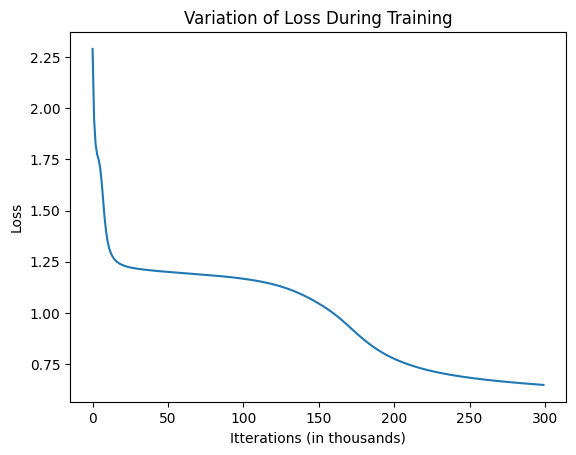

In [33]:
import matplotlib.pyplot as plt

plt.plot(range(300), loss_arr)
plt.xlabel("Itterations (in thousands)")
plt.ylabel("Loss")
plt.title("Variation of Loss During Training")
plt.show()

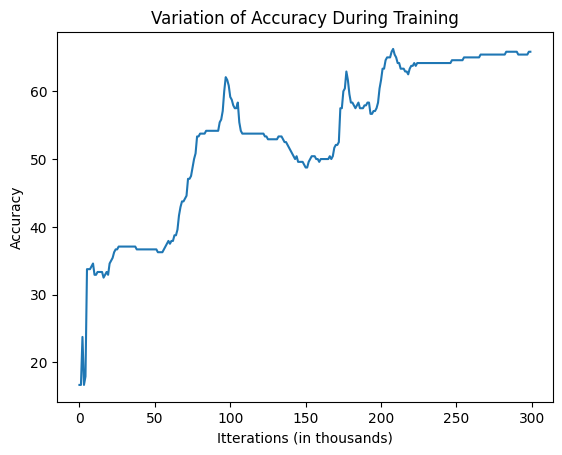

In [34]:
plt.plot(range(300), acc_arr)
plt.xlabel("Itterations (in thousands)")
plt.ylabel("Accuracy")
plt.title("Variation of Accuracy During Training")
plt.show()